In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import torchvision.datasets as datasets
from torchvision import models, transforms
from torchvision.utils import save_image, make_grid
from torch.optim.lr_scheduler import StepLR
from torch import autograd
from torch.autograd import Variable
from tensorboardX import SummaryWriter

from typing import Dict, Tuple
from tqdm import tqdm
import numpy as np
import time
import os
import random
from tabulate import tabulate

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

%matplotlib inline

if __name__ == "__main__":
    print("Torch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("CUDA version:", torch.version.cuda)
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.device_count() > 0 else "No GPU detected")



Torch version: 2.7.0+cu126
CUDA available: True
CUDA version: 12.6
Number of GPUs: 1
GPU name: NVIDIA GeForce RTX 4090


In [3]:
def fullwg(wg):
    waveguide_tensor = torch.tensor(wg, dtype=torch.float32)
    if waveguide_tensor.ndim == 3:
        waveguide_tensor = waveguide_tensor.squeeze()
    # Mirror over x-axis (vertical flip) to get bottom-right
    bottom_right = torch.flip(waveguide_tensor, dims=[0])

    # Stack top and bottom vertically to get right half
    right_half = torch.cat([waveguide_tensor, bottom_right], dim=0)  # shape [32, 16]

    # Mirror over y-axis (horizontal flip) to get left half
    left_half = torch.flip(right_half, dims=[1])  # shape [32, 16]

    # Concatenate left and right to get full waveguide
    full_waveguide = torch.cat([left_half, right_half], dim=1)  # shape [32, 32]

    # Plot the result
    plt.imshow(full_waveguide.numpy(), cmap='viridis')
    plt.title("Full Reconstructed Waveguide")
    plt.axis('off')
    # plt.colorbar()
    plt.show()
    return full_waveguide.numpy()

import torch
import matplotlib.pyplot as plt

def fullwg(wg, x_vals=None, y1_vals=None, y2_vals=None, l1=None, l2=None):
    waveguide_tensor = torch.tensor(wg, dtype=torch.float32)
    if waveguide_tensor.ndim == 3:
        waveguide_tensor = waveguide_tensor.squeeze()

    # Mirror over x-axis (vertical flip) to get bottom-right
    bottom_right = torch.flip(waveguide_tensor, dims=[0])

    # Stack top and bottom vertically to get right half
    right_half = torch.cat([waveguide_tensor, bottom_right], dim=0)  # shape [32, 16]

    # Mirror over y-axis (horizontal flip) to get left half
    left_half = torch.flip(right_half, dims=[1])  # shape [32, 16]

    # Concatenate left and right to get full waveguide
    full_waveguide = torch.cat([left_half, right_half], dim=1)  # shape [32, 32]

    # Set up subplots: 1 row, 3 columns
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    # Plot the waveguide
    axs[0].imshow(full_waveguide.numpy(), cmap='viridis')
    axs[0].set_title("Full Waveguide")
    axs[0].axis('off')

    # Plot first line graph (if provided)
    if x_vals is not None and y1_vals is not None:
        axs[1].plot(x_vals, y1_vals, 'r')
        axs[1].set_title(l1[0])
        axs[1].set_xlabel(l1[1])
        axs[1].set_ylabel(l1[2])
        axs[1].grid(True)

    # Plot second line graph (if provided)
    if x_vals is not None and y2_vals is not None:
        axs[2].plot(x_vals, y2_vals, 'b')
        axs[2].set_title(l2[0])
        axs[2].set_xlabel(l2[1])
        axs[2].set_ylabel(l2[2])
        axs[2].grid(True)

    plt.tight_layout()
    plt.show()

    return full_waveguide.numpy()



In [4]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def plot_generated_vs_true(cond, generated, title=''):
    cond = cond.squeeze().cpu().numpy()       # [8]
    generated = generated.squeeze().cpu().numpy()  # [8]

    indices = np.arange(8)

    plt.figure(figsize=(10, 5))
    plt.plot(indices, cond, 'ro-', label='True Condition')
    plt.plot(indices, generated, 'bo-', label='Generated')
    plt.xticks(indices)
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.title(f"Generated vs True Condition Vector {title}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_modes_and_weights(cond, generated, title=''):
    """
    Plot modes (indices 0–3) and weights (indices 4–7) on two separate axes.

    Args
    ----
    cond       : tensor of shape [1, 8]  (ground-truth)
    generated  : tensor of shape [1, 8]  (model prediction)
    """
    cond      = cond.squeeze().cpu().numpy()       # -> [8]
    generated = generated.squeeze().cpu().numpy()  # -> [8]

    modes_idx    = np.arange(4)          # 0,1,2,3
    weights_idx  = np.arange(4, 8)       # 4,5,6,7

    fig, (ax_modes, ax_weights) = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

    # ── Left axis: modes ──────────────────────────────────────────
    ax_modes.plot(modes_idx, cond[:4],      'ro-', label='True')
    ax_modes.plot(modes_idx, generated[:4], 'bo-', label='Generated')
    ax_modes.set_xticks(modes_idx)
    ax_modes.set_xticklabels([f'Mode {i}' for i in modes_idx])
    ax_modes.set_xlabel("Modes")
    ax_modes.set_ylabel("Value")
    ax_modes.set_title(f"Modes 0–3 {title}")
    ax_modes.grid(True)
    ax_modes.legend()

    # ── Right axis: weights ──────────────────────────────────────
    ax_weights.plot(weights_idx, cond[4:],      'ro-', label='True')
    ax_weights.plot(weights_idx, generated[4:], 'bo-', label='Generated')
    ax_weights.set_xticks(weights_idx)
    ax_weights.set_xticklabels([f'Weight {i-4}' for i in weights_idx])
    ax_weights.set_xlabel("Weights")
    ax_weights.set_title(f"Weights 0–3 {title}")
    ax_weights.grid(True)
    ax_weights.legend()

    plt.tight_layout()
    plt.show()

In [7]:
from waveguide_dataset import WaveguideDataset
dataset = WaveguideDataset('train_test_split.h5')

from cnn_v1 import Net4
from first_mode import Net4_Mode0Weight0

batch_size = 128
test_batch_size = 1000
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
device = 'cuda' if torch.cuda.is_available() else 'cpu'

mode0_model = Net4_Mode0Weight0().to(device)
mode0_model.load_state_dict(torch.load('models/only_top_mode.pth', map_location=torch.device(device)))
new_mode0_model = Net4_Mode0Weight0().to(device)
new_mode0_model.load_state_dict(torch.load('models/only_top_mode_correct_norm.pth', map_location=torch.device(device)))

eval_model = Net4().to(device)
eval_model.load_state_dict(torch.load('models/mode_cnn_even_deeper_network_200epoch.pth', map_location=torch.device(device)))


<All keys matched successfully>

/tmp/ipykernel_567799/2974752966.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  wg_tensor = torch.tensor(wg, dtype=torch.float32).view(1, 1, 32, 32).to(device)
/tmp/ipykernel_567799/2974752966.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  params_tensor = torch.tensor(params, dtype=torch.float32).unsqueeze(0).to(device)       # [1, 4]


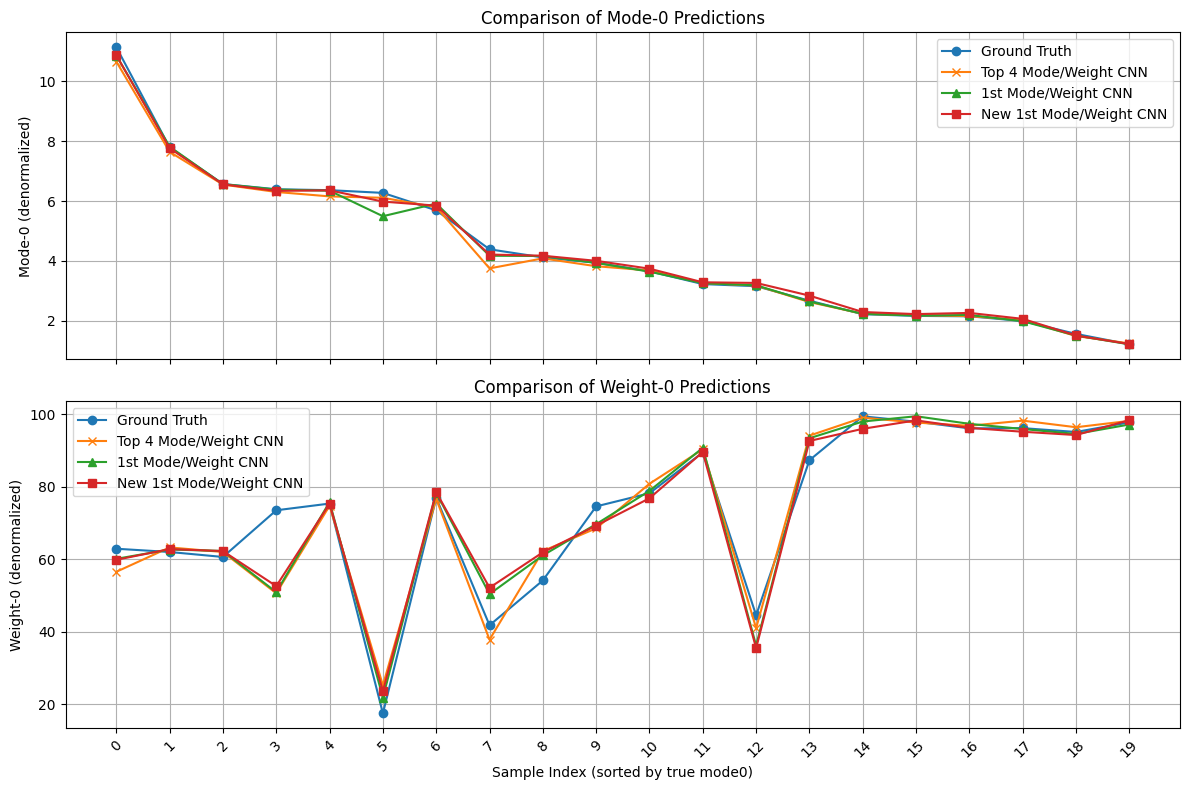

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

eval_model.eval()
mode0_model.eval()
new_mode0_model.eval()
# Grab 20 random indices
indices = random.sample(range(len(dataset)), 20)

samples = []
for idx in indices:
    cond_vec, params, wg = dataset[idx]

    # Get true (normalized) mode0 and weight0
    mode0_norm = cond_vec[0].item()
    weight0_norm = cond_vec[4].item()

    # Log-normalization stats
    mode_mean_log = float(dataset.meanm[0])
    mode_std_log  = float(dataset.stdm[0])
    wt_mean_log   = float(dataset.meanw[0])
    wt_std_log    = float(dataset.stdw[0])

    # Denormalize ground truth
    mode0_log = mode0_norm * mode_std_log + mode_mean_log
    weight0_log = weight0_norm * wt_std_log + wt_mean_log

    mode0_real = np.expm1(mode0_log)
    weight0_real = np.expm1(weight0_log)

    samples.append((mode0_real, weight0_real, params, wg))

# Sort by true mode0 descending
samples.sort(key=lambda x: x[0], reverse=True)

# Create lists for plotting
true_modes, true_weights = [], []
eval_modes, eval_weights = [], []
mode0_model_modes, mode0_model_weights = [], []
new_mode0_model_modes = []
new_mode0_model_weights = []


# Inference
with torch.no_grad():
    for mode0_true, weight0_true, params, wg in samples:
        # Prepare inputs
        wg_tensor = torch.tensor(wg, dtype=torch.float32).view(1, 1, 32, 32).to(device)


        params_tensor = torch.tensor(params, dtype=torch.float32).unsqueeze(0).to(device)       # [1, 4]
        const_tail = params_tensor[:, 1:]  # [1, 3]

        # ----- eval_model (8 outputs) -----
        full_pred = eval_model(wg_tensor, params_tensor)  # [1, 8]
        pred_mode0_full   = full_pred[0, 0].item()
        pred_weight0_full = full_pred[0, 4].item()

        # Denormalize full model outputs
        pred_mode0_log_full = pred_mode0_full * mode_std_log + mode_mean_log
        pred_weight0_log_full = pred_weight0_full * wt_std_log + wt_mean_log

        pred_mode0_real_full = np.expm1(pred_mode0_log_full)
        pred_weight0_real_full = np.expm1(pred_weight0_log_full)

        # ----- mode0_model (2 outputs) -----
        mode0_pred = mode0_model(wg_tensor, params_tensor)  # [1, 2]

        pred_mode0_model = mode0_pred[0, 0].item()
        pred_weight0_model = mode0_pred[0, 1].item()

        # Denormalize 2-output model
        pred_mode0_log_model = pred_mode0_model * mode_std_log + mode_mean_log
        pred_weight0_log_model = pred_weight0_model * wt_std_log + wt_mean_log

        pred_mode0_real_model = np.expm1(pred_mode0_log_model)
        pred_weight0_real_model = np.expm1(pred_weight0_log_model)

        # ----- new_mode0_model (2 outputs) -----
        new_pred = new_mode0_model(wg_tensor, params_tensor)  # [1, 2]

        pred_mode0_new = new_pred[0, 0].item()
        pred_weight0_new = new_pred[0, 1].item()

        # Denormalize new model outputs
        pred_mode0_log_new = pred_mode0_new * mode_std_log + mode_mean_log
        pred_weight0_log_new = pred_weight0_new * wt_std_log + wt_mean_log

        pred_mode0_real_new = np.expm1(pred_mode0_log_new)
        pred_weight0_real_new = np.expm1(pred_weight0_log_new)

        # Append for plotting
        new_mode0_model_modes.append(pred_mode0_real_new)
        new_mode0_model_weights.append(pred_weight0_real_new)


        # Append for plotting
        true_modes.append(mode0_true)
        true_weights.append(weight0_true)
        eval_modes.append(pred_mode0_real_full)
        eval_weights.append(pred_weight0_real_full)
        mode0_model_modes.append(pred_mode0_real_model)
        mode0_model_weights.append(pred_weight0_real_model)

# ----- PLOTTING -----
x = np.arange(20)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Mode-0 plot
ax1.plot(x, true_modes, label='Ground Truth', marker='o')
ax1.plot(x, eval_modes, label='Top 4 Mode/Weight CNN', marker='x')
ax1.plot(x, mode0_model_modes, label='1st Mode/Weight CNN', marker='^')
ax1.plot(x, new_mode0_model_modes, label='New 1st Mode/Weight CNN', marker='s')  # NEW
ax1.set_ylabel("Mode-0 (denormalized)")
ax1.set_title("Comparison of Mode-0 Predictions")
ax1.grid(True)
ax1.legend()

# Weight-0 plot
ax2.plot(x, true_weights, label='Ground Truth', marker='o')
ax2.plot(x, eval_weights, label='Top 4 Mode/Weight CNN', marker='x')
ax2.plot(x, mode0_model_weights, label='1st Mode/Weight CNN', marker='^')
ax2.plot(x, new_mode0_model_weights, label='New 1st Mode/Weight CNN', marker='s')  # NEW
ax2.set_ylabel("Weight-0 (denormalized)")
ax2.set_title("Comparison of Weight-0 Predictions")
ax2.set_xticks(x)
ax2.set_xticklabels([str(i) for i in x], rotation=45)
ax2.set_xlabel("Sample Index (sorted by true mode0)")
ax2.grid(True)
ax2.legend()


plt.tight_layout()
plt.show()


In [1]:
wavelengths = np.array(np.linspace(-1.9, 1.5, 100))  
idx                   = random.randrange(len(dataset))
cond_vec, params, wg  = dataset[idx]    

wg_tensor = torch.tensor(wg, dtype=torch.float32)
wg_np = wg.numpy()

if wg_tensor.ndim == 2:
    wg_tensor = wg_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, 32, 32]
elif wg_tensor.ndim == 3:
    wg_tensor = wg_tensor.unsqueeze(0)               # [1, 1, 32, 32]
wg_tensor = wg_tensor.to(device)
# print(params)
const_tail  = torch.tensor(params[1:], dtype=torch.float32).unsqueeze(0).to(device) 
mode0_list = []
weight0_list = []
wavelength_list = []
new_mode0_model.eval()

#################
pt = params.unsqueeze(0).to(device)              # [1, 4]
wg_tensor = wg_tensor.to(device)                 # [1, 1, 32, 32]

# Get model output (normalized)
with torch.no_grad():
    pred_norm = new_mode0_model(wg_tensor, pt)       # [1, 2]

# Print normalized output
print("Model output (normalized):", pred_norm.cpu())

# Fetch normalization stats as scalars
mode_mean_log = float(dataset.meanm[0])
mode_std_log  = float(dataset.stdm[0])
wt_mean_log   = float(dataset.meanw[0])
wt_std_log    = float(dataset.stdw[0])

# Denormalize model output
mode0_log   = pred_norm[0, 0].item() * mode_std_log + mode_mean_log
weight0_log = pred_norm[0, 1].item() * wt_std_log + wt_mean_log

mode0_real   = np.expm1(mode0_log)
weight0_real = np.expm1(weight0_log)

print(f"Model output (denormalized):   Mode0 = {mode0_real:.4f}, Weight0 = {weight0_real:.4f}")

# Also denormalize the true values from dataset
true_mode0_log   = cond_vec[0].item() * mode_std_log + mode_mean_log
true_weight0_log = cond_vec[4].item() * wt_std_log + wt_mean_log

true_mode0   = np.expm1(true_mode0_log)
true_weight0 = np.expm1(true_weight0_log)

print(f"True values (denormalized):    Mode0 = {true_mode0:.4f}, Weight0 = {true_weight0:.4f}")

#################

with torch.no_grad():
    for lam in wavelengths:  # iterate over λ list
        lam_tensor = torch.tensor([[lam]], dtype=torch.float32).to(device)  # [1,1]
        params_tensor = torch.cat([lam_tensor, const_tail], dim=1).to(device)  # [1,4]
        
        # Optional: get un-normalized wavelength for plotting or analysis
        params_norm = dataset.denormalize_params(params_tensor.cpu())
        wavelength_list.append(params_norm[0, 0].item())

        # Model output: normalized [mode0, weight0], shape [1,2]
        pred_norm = new_mode0_model(wg_tensor, params_tensor)  # [1,2]

        # Convert normalization stats to scalars
        mode_mean_log = float(dataset.meanm[0])
        mode_std_log  = float(dataset.stdm[0])
        wt_mean_log   = float(dataset.meanw[0])
        wt_std_log    = float(dataset.stdw[0])

        # Step 1: Undo z-score (get log1p values)
        mode0_log   = pred_norm[0, 0].item() * mode_std_log + mode_mean_log
        weight0_log = pred_norm[0, 1].item() * wt_std_log + wt_mean_log

        # Step 2: Undo log1p (get original values)
        mode0_real   = np.expm1(mode0_log)
        weight0_real = np.expm1(weight0_log)

        # Store results
        mode0_list.append(np.sqrt(mode0_real))
        weight0_list.append(weight0_real)

wavelengths = np.array(wavelength_list)
neff = np.array(mode0_list)       

lm0 = ['1st order n_eff vs Wavelength', 'Wavelength (um)', '1st order n_eff']
lw0 = ["Weight vs Wavelength", "Wavelength (um)", "1st order n_eff weight"]

full_wg = fullwg(wg, wavelengths, mode0_list, weight0_list, lm0, lw0)



NameError: name 'np' is not defined

torch.Size([8])
-1.1804146766662598
1.1260210275650024


/var/folders/4n/fq2wsfws1s5fqn5wt0ymgb7c0000gn/T/ipykernel_62778/2912386805.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  wg_tensor = torch.tensor(wg, dtype=torch.float32)
/var/folders/4n/fq2wsfws1s5fqn5wt0ymgb7c0000gn/T/ipykernel_62778/2912386805.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  const_tail  = torch.tensor(params[1:], dtype=torch.float32).unsqueeze(0).to(device)        # [1,3]


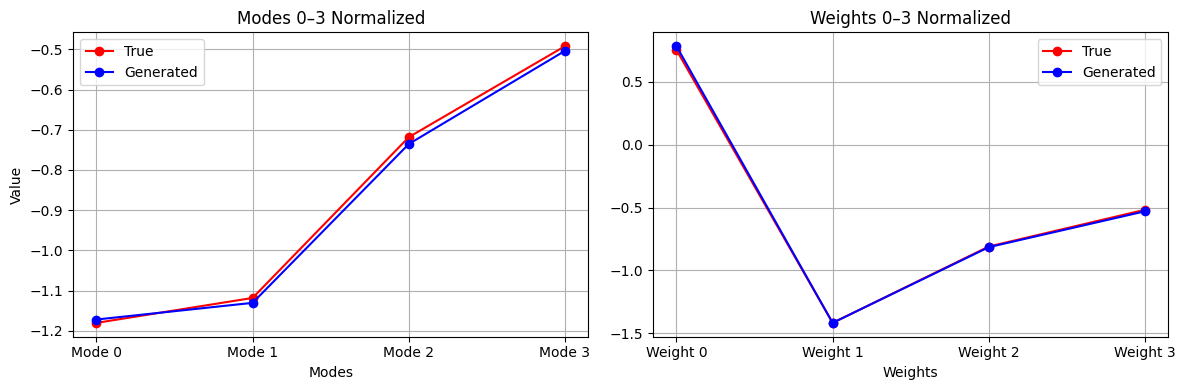

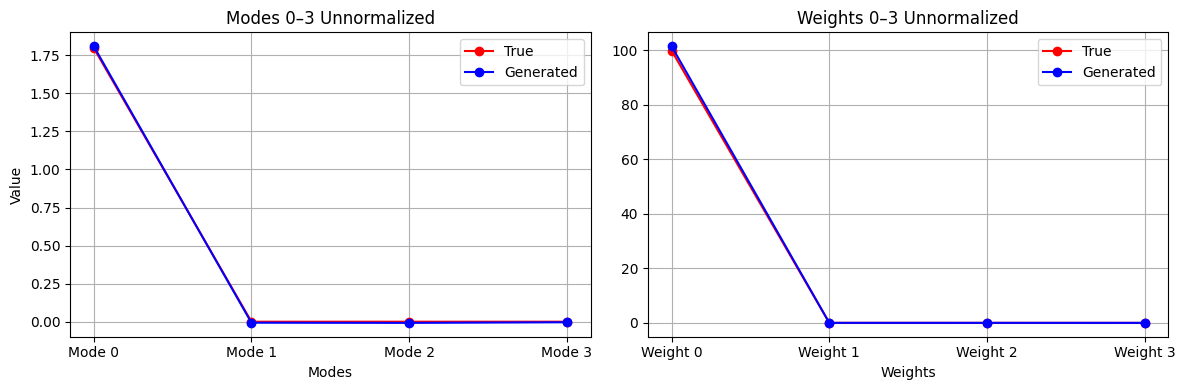

In [ ]:
wavelengths = np.array(np.linspace(-1.9, 1.5, 100))  
idx                   = random.randrange(len(dataset))
cond_vec, params, wg  = dataset[idx]           # params is shape (4,) with λ at index 0

denorm_real_cond = dataset.denormalize_cond(cond_vec)
denorm_real_param = dataset.denormalize_params(params)

print(cond_vec.size())
print(cond_vec[0].item())
print(params[0].item())

# freeze everything except wavelength
wg_tensor = torch.tensor(wg, dtype=torch.float32)
wg_np = wg.numpy()

if wg_tensor.ndim == 2:
    wg_tensor = wg_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, 32, 32]
elif wg_tensor.ndim == 3:
    wg_tensor = wg_tensor.unsqueeze(0)               # [1, 1, 32, 32]
wg_tensor = wg_tensor.to(device)
# print(params)
const_tail  = torch.tensor(params[1:], dtype=torch.float32).unsqueeze(0).to(device)        # [1,3]

# container for mode-0 vs wavelength
mode0_list = []
weight0_list = []
wavelength_list = []
all = []

eval_model.eval()
pt = params.unsqueeze(0)

with torch.no_grad():
    mode_pred = eval_model(wg_tensor, pt)

# plt.plot(cond_vec)
denorm_pred = dataset.denormalize_cond(mode_pred)

plot_modes_and_weights(cond_vec, mode_pred, 'Normalized')
plot_modes_and_weights(denorm_real_cond, denorm_pred, "Unnormalized")

with torch.no_grad():
    for lam in wavelengths:                                   # iterate over λ list
        lam_tensor = torch.tensor([[lam]], dtype=torch.float32).to(device)  # [1,1]
        params_tensor = torch.cat([lam_tensor, const_tail], dim=1)          # [1,4]
        params_norm = dataset.denormalize_params(params_tensor)
        mode_pred = dataset.denormalize_cond(eval_model(wg_tensor, params_tensor))     # shape [1,8] (modes+weights)
        mode0_list.append(mode_pred[0, 0].item())             # first index mode
        weight0_list.append(mode_pred[0,4].item())
        all.append(mode_pred)
        wavelength_list.append(params_norm[0,0].item())



# print(all[0].size())
# stacked = torch.cat(all, dim=0)  # shape [N, 8]

# # Plot each component (0 to 7) across the index of the list
# plt.figure(figsize=(15, 10))
# for i in range(8):
#     plt.axhline(denorm_real_cond[i], color='r')
#     plt.subplot(2, 4, i + 1)
#     plt.plot(wavelength_list,stacked[:, i].cpu().numpy())
#     plt.title(f"Index {i}")
#     plt.xlabel("Wavelength")
#     plt.ylabel(f"Value {i}")
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

# mode0_list now holds mode-0 value for every λ in wavelengths
# print("λ (µm)  |  mode-0")
# for lam, m0 in zip(wavelength_list, mode0_list):
#     print(f"{lam:6.3f}  |  {m0:.6f}")


/tmp/ipykernel_514826/2933081429.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  waveguide_tensor = torch.tensor(wg, dtype=torch.float32)


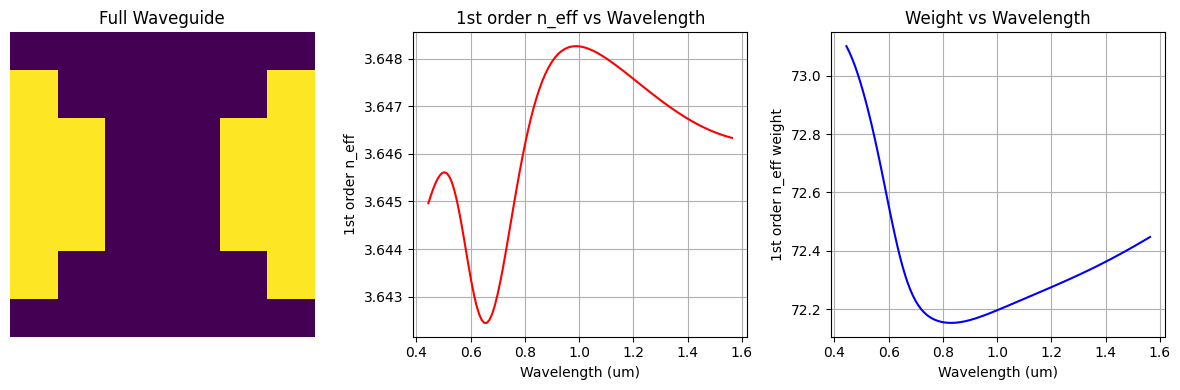

In [ ]:
import numpy as np

# Arrays of wavelength in meters and neff (same length)
# wavelengths = np.array(np.linspace(1.3e-6,1.6e-6,100))     # e.g., np.linspace(1.3e-6, 1.6e-6, 100)
wavelengths = np.array(wavelength_list)
neff = np.array(mode0_list)            # from your solver
omega = 2 * np.pi * 3e8 / wavelengths  # Angular frequency

beta = 2 * np.pi * neff / wavelengths

# Sort if not already sorted
# sorted_indices = np.argsort(omega)
# omega = omega[sorted_indices]
# beta = beta[sorted_indices]

# Numerical derivative dβ/dω
d_beta_d_omega = np.gradient(beta, omega)

# Group index
ng = 3e8 * d_beta_d_omega

# Plot
# import matplotlib.pyplot as plt
# plt.plot(wavelengths, mode0_list)
# plt.xlabel("Wavelength (um)")
# plt.ylabel("1st order n_eff")
# plt.title("1st order n_eff vs Wavelength")
# plt.grid(True)
# plt.show()

# plt.plot(wavelengths, weight0_list)
# plt.xlabel("Wavelength (um)")
# plt.ylabel("1st order n_eff weight")
# plt.title("Weight vs Wavelength")
# plt.grid(True)
# plt.show()
c


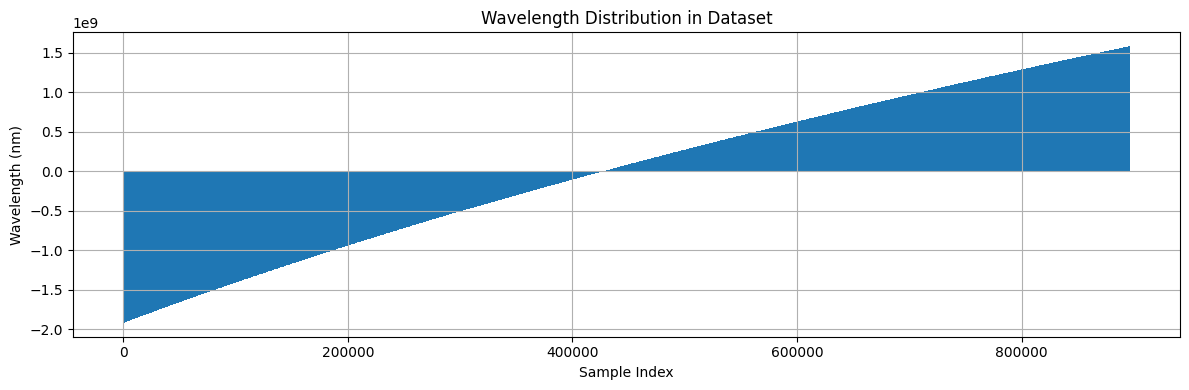

In [35]:
wavelengths = [dataset[i][1][0] for i in range(len(dataset))]  # dataset[i][1] = params

# Convert to numpy for better handling
import numpy as np
wavelengths = np.array(wavelengths)

# Optional: sort for better visual structure
sorted_indices = np.argsort(wavelengths)
wavelengths_sorted = wavelengths[sorted_indices]

# Plot as bar chart
plt.figure(figsize=(12, 4))
plt.bar(range(len(wavelengths_sorted)), wavelengths_sorted * 1e9, width=1.0)
plt.xlabel("Sample Index")
plt.ylabel("Wavelength (nm)")
plt.title("Wavelength Distribution in Dataset")
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
print(min(wavelengths_sorted))
print(max(wavelengths_sorted))

-1.9166535
1.5828345
